In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [219]:
path = "../dataset/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
df = pd.read_csv(path)

In [220]:

# Compute derived columns
df['arrival_time'] = df['end_timestamp'] - df['duration']
df.sort_values(by='arrival_time', inplace=True)
hour_trace = 4
df['trace_id'] = (df['arrival_time'] // (hour_trace * 3600)).astype(int)
df['arrival_time_norm'] = df['arrival_time'] - (df['trace_id'] * hour_trace * 3600)




In [221]:
best_groups = []

# Define categories (min_req, max_req, num_func)
categories = [
    (50, 80, 2),    # Category 1: 2 functions, 50-80 requests
    (90, 150, 2),  # Category 2: 2 functions, 100-150 requests
    (280, 500, 3)   # Category 3: 3 functions, 300-500 requests
]


for cat_idx, (min_req, max_req, num_func) in enumerate(categories):
    best_score = float('inf')
    best_group = None
    for trace_id in df['trace_id'].unique():
        trace = df[df['trace_id'] == trace_id]
        func_counts = trace['func'].value_counts()
        candidate_funcs = func_counts[(func_counts >= min_req) & (func_counts <= max_req)].index.tolist()
        if len(candidate_funcs) < num_func:
            continue
        # Get first request times
        func_first_times = trace.groupby('func')['arrival_time'].min()
        func_first_times = func_first_times[func_first_times.index.isin(candidate_funcs)]
        # Try all combinations (efficient for small num_func)
        for funcs in combinations(func_first_times.index, num_func):
            times = func_first_times[list(funcs)].values
            similarity_score = times.max() - times.min()  # Smaller is better
            if similarity_score < best_score:
                best_score = similarity_score
                best_group = {
                    'category': cat_idx+1,
                    'trace_id': trace_id,
                    'functions': list(funcs),
                    'start_times': list(times),
                    'similarity_score': similarity_score
                }
    if best_group is not None:
        best_groups.append(best_group)

# Print best group for each category
for entry in best_groups:
    print(
        f"Category {entry['category']}: Trace {entry['trace_id']} | "
        f"Functions: {entry['functions']} | "
        f"Start times: {np.round(entry['start_times'], 1)} | "
        f"Similarity Score (seconds): {entry['similarity_score']}"
    )

# Final result
result_df = pd.DataFrame(best_groups)
print(result_df)

Category 1: Trace 45 | Functions: ['49535532e285d1ef68b0a7b8c3bc3973b36ec38a4c594ec9f1412084c27036ff', 'cd9f7f333d59aede8088772edac3bff78c45e2dad8eb498b450b9af511452a36'] | Start times: [648000. 648000.] | Similarity Score (seconds): 1.1958181858062744e-06
Category 2: Trace 52 | Functions: ['48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037d94ad2e76f44dd8946', '4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa593e23d81211eb3e87'] | Start times: [754470.3 754470.3] | Similarity Score (seconds): 0.0005719643086194992
Category 3: Trace 20 | Functions: ['1cf618f9ee318fecbc31aa059ded8328581b9a9b092f1069b9f7679b6f89e52e', 'b89efb5e9d1b7e5900ef441b098d4c8b01600af5e673a9f9d607b3598f0fe548', 'e5298aafdbabecd1465ab0eeb24d7633ac7de0284f7ee075209b119c297a3622'] | Start times: [288669.3 288654.9 288658.1] | Similarity Score (seconds): 14.35918101691641
   category  trace_id                                          functions  \
0         1        45  [49535532e285d1ef68b0a7b8c3bc3973b36ec38a4c594...   
1 

/tmp/ipykernel_909102/4029340866.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


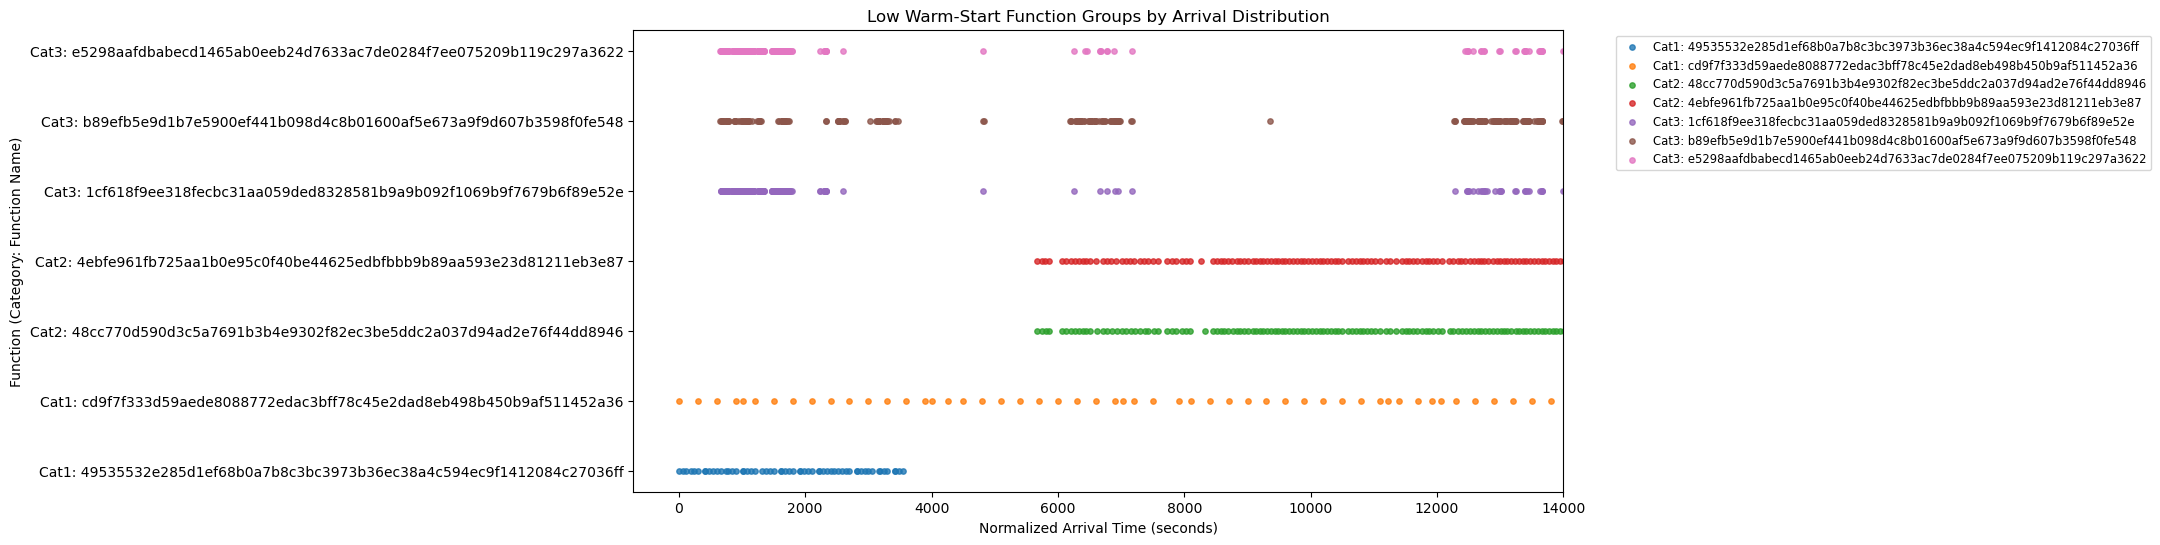

In [222]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

all_funcs = []
all_func_colors = {}
colors = plt.cm.tab10.colors
color_idx = 0

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    cat = entry['category']
    # if cat != 3:
    #     continue
    funcs = entry['functions']
    cat_color = colors[cat % len(colors)]
    for func in funcs:
        func_label = f"Cat{cat}: {func}"
        all_funcs.append(func_label)
        all_func_colors[func_label] = colors[color_idx % len(colors)]
        color_idx += 1
        func_df = df[(df['trace_id'] == trace_id) & (df['func'] == func)]
        plt.scatter(
            func_df['arrival_time_norm'],
            [func_label] * len(func_df),
            s=15,
            color=all_func_colors[func_label],
            label=func_label,
            alpha=0.8
        )


# Optional: Set max x-axis range
plt.xlim(right=14000)

# Deduplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.xlabel("Normalized Arrival Time (seconds)")
plt.ylabel("Function (Category: Function Name)")
plt.title("Low Warm-Start Function Groups by Arrival Distribution")
plt.tight_layout()
plt.show()


In [223]:
data = ['alexnet', 'efficientnet', 'bert', 'distilgpt2', 'resnet50', 'googlenet', 'inception']
i = 0 
res = []
name_header = ['func','trace_id','category_id','id','memory','file_path']
for l in best_groups:
    total_subset = len(l['functions'])
    
    for k in range(0,total_subset):
        temp = []
        trace_id = l['trace_id']
        category_id = l['category']
        func = data[i]
        memory = 1024
        file_path = data[i]+".py"
        id_val = l['functions'][k]
        i += 1
        res.append([func, trace_id, category_id, id_val, memory, file_path])

res_df = pd.DataFrame(res,columns=name_header)
func_dict = res_df.set_index('id')['func'].to_dict()
func_dict

{'49535532e285d1ef68b0a7b8c3bc3973b36ec38a4c594ec9f1412084c27036ff': 'alexnet',
 'cd9f7f333d59aede8088772edac3bff78c45e2dad8eb498b450b9af511452a36': 'efficientnet',
 '48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037d94ad2e76f44dd8946': 'bert',
 '4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa593e23d81211eb3e87': 'distilgpt2',
 '1cf618f9ee318fecbc31aa059ded8328581b9a9b092f1069b9f7679b6f89e52e': 'resnet50',
 'b89efb5e9d1b7e5900ef441b098d4c8b01600af5e673a9f9d607b3598f0fe548': 'googlenet',
 'e5298aafdbabecd1465ab0eeb24d7633ac7de0284f7ee075209b119c297a3622': 'inception'}

In [224]:
best_df_list = []

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    funcs = entry['functions']
    filtered = df[(df['trace_id'] == trace_id) & (df['func'].isin(funcs))]
    best_df_list.append(filtered)

# Concatenate all the filtered DataFrames
best_df = pd.concat(best_df_list, ignore_index=True)

# Optional: Sort by trace_id and arrival_time_norm for convenience
best_df = best_df.sort_values(by=['trace_id', 'func', 'arrival_time_norm']).reset_index(drop=True)

# Corrected normalization of arrival_time (if needed again)
best_df['arrival_time'] = best_df['arrival_time_norm']




In [225]:
best_df['func_id'] = best_df['func'].map(func_dict)
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id
0,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288669.291859,0.038,669.253859,20,669.253859,resnet50
1,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288671.219332,0.046,671.173332,20,671.173332,resnet50
2,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288672.530376,0.037,672.493376,20,672.493376,resnet50
3,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288674.598364,0.040,674.558364,20,674.558364,resnet50
4,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288676.455732,0.039,676.416732,20,676.416732,resnet50
...,...,...,...,...,...,...,...,...
1287,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,762967.864237,64.564,14103.300237,52,14103.300237,distilgpt2
1288,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,763042.971781,75.071,14167.900781,52,14167.900781,distilgpt2
1289,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,763100.669656,57.672,14242.997656,52,14242.997656,distilgpt2
1290,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,763154.168905,53.469,14300.699905,52,14300.699905,distilgpt2


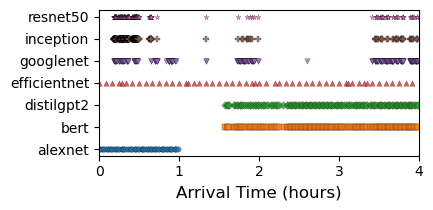

In [226]:
import matplotlib.pyplot as plt
import itertools

# Convert seconds to hours for x-axis
best_df['arrival_time_hr'] = best_df['arrival_time'] / 3600.0

# Marker styles to cycle through
markers = itertools.cycle(('o', 's', 'D', '^', 'v', 'P', '*'))

plt.figure(figsize=(4.5, 2.2))

# Plot each function group with style
for func_id, group in best_df.groupby('func_id'):
    plt.scatter(
        group['arrival_time_hr'],
        [func_id]*len(group),
        s=15,
        alpha=0.75,
        marker=next(markers),
        edgecolors='k',
        linewidths=0.2
    )

plt.xlabel("Arrival Time (hours)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 4)
# plt.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
# plt.savefig("graphs_images/similar_dataset_graph.png", dpi=300, bbox_inches='tight')
plt.show()


In [227]:
category_counts = best_df['func_id'].value_counts().sort_index()
category_counts

func_id
alexnet          59
bert            128
distilgpt2      128
efficientnet     53
googlenet       308
inception       306
resnet50        310
Name: count, dtype: int64

In [228]:
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id,arrival_time_hr
0,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288669.291859,0.038,669.253859,20,669.253859,resnet50,0.185904
1,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288671.219332,0.046,671.173332,20,671.173332,resnet50,0.186437
2,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288672.530376,0.037,672.493376,20,672.493376,resnet50,0.186804
3,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288674.598364,0.040,674.558364,20,674.558364,resnet50,0.187377
4,96149d3ed4f00afb92f12856101e693e93c4683f030ae6...,1cf618f9ee318fecbc31aa059ded8328581b9a9b092f10...,288676.455732,0.039,676.416732,20,676.416732,resnet50,0.187894
...,...,...,...,...,...,...,...,...,...
1287,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,762967.864237,64.564,14103.300237,52,14103.300237,distilgpt2,3.917583
1288,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,763042.971781,75.071,14167.900781,52,14167.900781,distilgpt2,3.935528
1289,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,763100.669656,57.672,14242.997656,52,14242.997656,distilgpt2,3.956388
1290,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,4ebfe961fb725aa1b0e95c0f40be44625edbfbbb9b89aa...,763154.168905,53.469,14300.699905,52,14300.699905,distilgpt2,3.972417


In [229]:
res_df.to_csv('../dataset/similar_gen_functions.csv', index=False)
best_df.to_csv('../dataset/similar_gen_df.csv', index=False)